# DisplacedVertex Training Results

This notebook evaluates all trained DisplacedVertex GNN checkpoints in `models/`.

It automatically selects the correct dataset and split file **based on the model name**:

- **cartesian/default models** → `data/*.h5` + `split_displaced_vertex_seed12345.npz`
- **cylindrical models** → `data_cylindrical/*.h5` + `split_displaced_vertex_cylindrical_seed12345.npz`
- **polar models** → `data_polar/*.h5` + `split_displaced_vertex_polar_seed12345.npz`

For each checkpoint, it computes:

- global MAPE
- per-variable MAPE
- MAE / RMSE
- residual plots
- prediction vs target plots

It also handles angular targets such as `phi` using wrapped angular differences.


In [1]:
# ------------------------------
# Configuration
# ------------------------------

MODELS_DIR = "models"
EVAL_SPLIT = "val"   # "val" or "test"

# Root folders / split files
DATASETS = {
    "cartesian": {
        "data_glob": "data/*.h5",
        "split_file": "data/split_displaced_vertex_seed12345.npz",
    },
    "cylindrical": {
        "data_glob": "data_cylindrical/*.h5",
        "split_file": "data_cylindrical/split_displaced_vertex_cylindrical_seed12345.npz",
    },
    "polar": {
        "data_glob": "data_polar/*.h5",
        "split_file": "data_polar/split_displaced_vertex_polar_seed12345.npz",
    },
}

DEVICE = "cuda"   # falls back to cpu automatically
MAPE_EPS = 1e-6
MAX_SCATTER_POINTS = 5000  # subsample for plots if dataset is large


In [2]:
import os
import glob
import math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dv_training_utils import H5EventDataset, collate_one, DisplacedVertexGNN

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
# ------------------------------
# Helpers
# ------------------------------

def infer_coordinate_system_from_name(model_name: str) -> str:
    name = model_name.lower()
    if "cylindrical" in name:
        return "cylindrical"
    if "polar" in name:
        return "polar"
    return "cartesian"


def wrap_angle_diff(pred, target):
    return (pred - target + np.pi) % (2.0 * np.pi) - np.pi


def get_angle_indices(labels):
    angle_names = {"phi", "theta"}
    return [i for i, lab in enumerate(labels) if str(lab).lower() in angle_names]


def compute_metrics(preds, targets, labels, mape_eps=1e-6):
    preds = np.asarray(preds, dtype=np.float64)
    targets = np.asarray(targets, dtype=np.float64)
    labels = [str(x) for x in labels]

    diff = preds - targets
    angle_idx = get_angle_indices(labels)
    for i in angle_idx:
        diff[:, i] = wrap_angle_diff(preds[:, i], targets[:, i])

    abs_diff = np.abs(diff)
    sq_diff = diff ** 2

    denom = np.maximum(np.abs(targets), mape_eps)
    ape = abs_diff / denom

    global_mape = 100.0 * ape.mean()
    per_var_mape = 100.0 * ape.mean(axis=0)
    global_mae = abs_diff.mean()
    per_var_mae = abs_diff.mean(axis=0)
    global_rmse = np.sqrt(sq_diff.mean())
    per_var_rmse = np.sqrt(sq_diff.mean(axis=0))

    return {
        "global_mape": global_mape,
        "per_var_mape": per_var_mape,
        "global_mae": global_mae,
        "per_var_mae": per_var_mae,
        "global_rmse": global_rmse,
        "per_var_rmse": per_var_rmse,
        "diff": diff,
        "abs_diff": abs_diff,
    }


_dataset_cache = {}

def load_eval_loader_for_coordinate_system(coord_system: str, eval_split: str):
    if (coord_system, eval_split) in _dataset_cache:
        return _dataset_cache[(coord_system, eval_split)]

    cfg = DATASETS[coord_system]
    paths = sorted(glob.glob(cfg["data_glob"]))
    if not paths:
        raise FileNotFoundError(f"No H5 files matched {cfg['data_glob']}")

    split_file = cfg["split_file"]
    if not os.path.exists(split_file):
        raise FileNotFoundError(f"Split file not found: {split_file}")

    dataset = H5EventDataset(paths)
    split = np.load(split_file, allow_pickle=True)

    if eval_split == "val":
        if "val_idx" not in split:
            raise KeyError(f"'val_idx' not found in {split_file}")
        indices = split["val_idx"]
    elif eval_split == "test":
        if "test_idx" not in split:
            raise KeyError(f"'test_idx' not found in {split_file}")
        indices = split["test_idx"]
    else:
        raise ValueError("EVAL_SPLIT must be 'val' or 'test'")

    eval_ds = torch.utils.data.Subset(dataset, indices.tolist())
    loader = torch.utils.data.DataLoader(
        eval_ds,
        batch_size=1,
        shuffle=False,
        collate_fn=collate_one,
        num_workers=0,
    )

    bundle = {
        "paths": paths,
        "split_file": split_file,
        "dataset": dataset,
        "eval_ds": eval_ds,
        "loader": loader,
        "n_events": len(eval_ds),
    }
    _dataset_cache[(coord_system, eval_split)] = bundle
    return bundle


In [4]:
# ------------------------------
# Model loading / evaluation
# ------------------------------

def build_model_from_checkpoint(ckpt):
    model = DisplacedVertexGNN(
        xdim=ckpt["xdim"],
        edim=ckpt["edim"],
        hdim=ckpt["hidden_dim"],
        n_layers=ckpt["layers"],
        dropout=ckpt["dropout"],
        layer_type=ckpt["layer_type"],
        gat_heads=ckpt.get("gat_heads", 4),
        sage_aggr=ckpt.get("sage_aggr", "mean"),
        edgeconv_aggr=ckpt.get("edgeconv_aggr", "mean"),
        pool=ckpt.get("pool", "meanmax"),
        use_fourier=ckpt.get("fourier", False),
        fourier_base=ckpt.get("fourier_base", 3.0),
        fourier_min_exp=ckpt.get("fourier_min_exp", -6),
        fourier_max_exp=ckpt.get("fourier_max_exp", 6),
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    return model


def load_checkpoint_compat(model_path):
    # PyTorch < 2.0 does not accept the weight_only argument.
    try:
        return torch.load(model_path, map_location="cpu", weight_only=False)
    except TypeError:
        return torch.load(model_path, map_location="cpu")


def evaluate_model(model_path, eval_split="val", mape_eps=1e-6):
    model_name = os.path.basename(model_path)
    inferred_coord = infer_coordinate_system_from_name(model_name)

    bundle = load_eval_loader_for_coordinate_system(inferred_coord, eval_split)
    loader = bundle["loader"]

    ckpt = load_checkpoint_compat(model_path)
    model = build_model_from_checkpoint(ckpt).to(device)
    model.eval()

    labels = ckpt.get("target_order", None)
    if labels is None:
        coord = str(ckpt.get("coordinate_system", inferred_coord)).lower()
        if coord == "cylindrical":
            labels = ["rho", "phi", "z"]
        elif coord == "polar":
            labels = ["r", "theta", "phi"]
        else:
            labels = ["x", "y", "z"]

    labels = [str(x) for x in labels]

    target_mean = ckpt.get("target_mean", torch.zeros(3)).cpu().numpy()
    target_std = ckpt.get("target_std", torch.ones(3)).cpu().numpy()
    normalize_target = bool(ckpt.get("normalize_target", False))

    preds = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device, non_blocking=True)
            edge_index = batch["edge_index"].to(device, non_blocking=True)
            edge_attr = batch["edge_attr"].to(device, non_blocking=True)
            y = batch["y_vertex"].to(device, non_blocking=True).float()

            pred = model(x, edge_index, edge_attr).detach().cpu().numpy()
            y_np = y.detach().cpu().numpy()

            pred = np.asarray(pred).reshape(1, -1)
            y_np = np.asarray(y_np).reshape(1, -1)

            if normalize_target:
                pred = pred * target_std.reshape(1, -1) + target_mean.reshape(1, -1)

            preds.append(pred[0])
            targets.append(y_np[0])

    preds = np.asarray(preds, dtype=np.float64)
    targets = np.asarray(targets, dtype=np.float64)

    metrics = compute_metrics(preds, targets, labels, mape_eps=mape_eps)

    out = {
        "model_path": model_path,
        "model_name": model_name,
        "coordinate_system": inferred_coord,
        "labels": labels,
        "preds": preds,
        "targets": targets,
        "metrics": metrics,
        "dataset_info": bundle,
    }
    return out


In [5]:
# ------------------------------
# Evaluate all checkpoints
# ------------------------------

model_paths = sorted(glob.glob(os.path.join(MODELS_DIR, "*.pt")))
if not model_paths:
    raise FileNotFoundError(f"No .pt files found in {MODELS_DIR}")

all_results = []
result_store = {}

for model_path in model_paths:
    print(f"Evaluating {model_path} ...")
    res = evaluate_model(model_path, eval_split=EVAL_SPLIT, mape_eps=MAPE_EPS)
    result_store[res["model_name"]] = res

    row = {
        "model": res["model_name"],
        "coordinate_system": res["coordinate_system"],
        "eval_split": EVAL_SPLIT,
        "n_events": res["dataset_info"]["n_events"],
        "data_glob": DATASETS[res["coordinate_system"]]["data_glob"],
        "split_file": DATASETS[res["coordinate_system"]]["split_file"],
        "global_mape": res["metrics"]["global_mape"],
        "global_mae": res["metrics"]["global_mae"],
        "global_rmse": res["metrics"]["global_rmse"],
    }

    for lab, val in zip(res["labels"], res["metrics"]["per_var_mape"]):
        row[f"mape_{lab}"] = val
    for lab, val in zip(res["labels"], res["metrics"]["per_var_mae"]):
        row[f"mae_{lab}"] = val
    for lab, val in zip(res["labels"], res["metrics"]["per_var_rmse"]):
        row[f"rmse_{lab}"] = val

    all_results.append(row)

results_df = pd.DataFrame(all_results).sort_values(["coordinate_system", "global_mape", "model"]).reset_index(drop=True)
results_df


Evaluating models/displaced_vertex_cylindrical_gnn_20260316-125309.pt ...


/tmp/ipykernel_927546/2213403287.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(model_path, map_location="cpu", weight_only=False)
/tmp/ipykernel_927

Evaluating models/displaced_vertex_gnn_20260312-175540.pt ...
Evaluating models/displaced_vertex_polar_gnn_20260314-091339.pt ...


,model,coordinate_system,eval_split,n_events,data_glob,split_file,global_mape,global_mae,global_rmse,mape_rho,...,mae_x,mae_y,rmse_x,rmse_y,mape_r,mape_theta,mae_r,mae_theta,rmse_r,rmse_theta
0,displaced_vertex_gnn_20260312-175540.pt,cartesian,val,4943,data/*.h5,data/split_displaced_vertex_seed12345.npz,2444.790473,0.384520,1.118442,NaN,...,0.240109,0.249416,0.660927,0.683629,NaN,NaN,NaN,NaN,NaN,NaN
1,displaced_vertex_cylindrical_gnn_20260316-1253...,cylindrical,val,4943,data_cylindrical/*.h5,data_cylindrical/split_displaced_vertex_cylind...,2503.592897,0.865872,1.524537,5487.561639,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,displaced_vertex_polar_gnn_20260314-091339.pt,polar,val,4943,data_polar/*.h5,data_polar/split_displaced_vertex_polar_seed12...,572.625874,0.900629,1.415203,NaN,...,NaN,NaN,NaN,NaN,735.851677,561.729024,0.76551,0.650766,1.696113,0.932096


In [6]:
# Compact ranking view
rank_cols = ["model", "coordinate_system", "global_mape", "global_mae", "global_rmse"]
display(results_df[rank_cols].sort_values("global_mape").reset_index(drop=True))


,model,coordinate_system,global_mape,global_mae,global_rmse
0,displaced_vertex_polar_gnn_20260314-091339.pt,polar,572.625874,0.900629,1.415203
1,displaced_vertex_gnn_20260312-175540.pt,cartesian,2444.790473,0.384520,1.118442
2,displaced_vertex_cylindrical_gnn_20260316-1253...,cylindrical,2503.592897,0.865872,1.524537


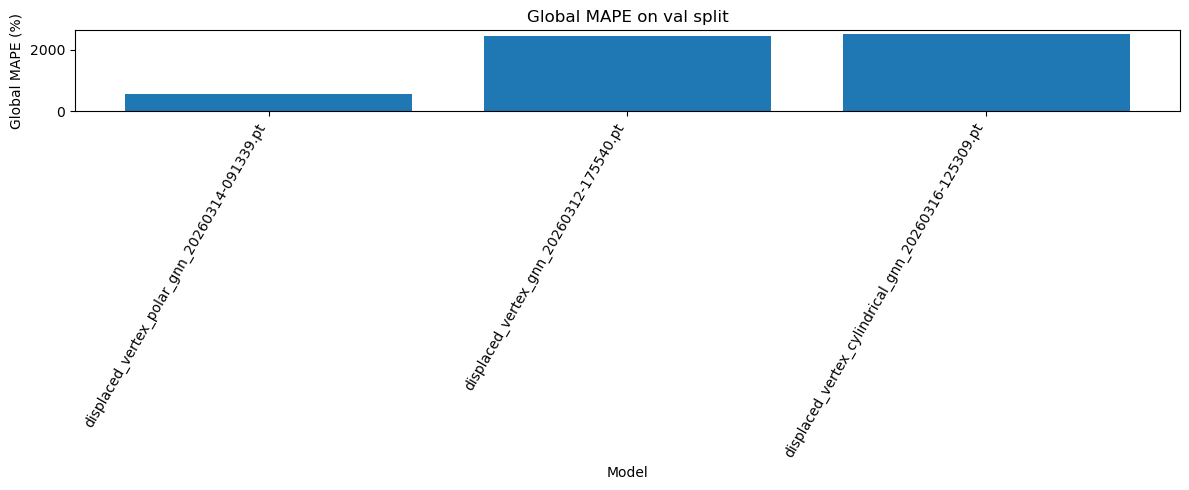

In [7]:
# ------------------------------
# Plot: Global MAPE comparison
# ------------------------------

plot_df = results_df.sort_values("global_mape").reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["model"].astype(str), plot_df["global_mape"].astype(float))
plt.ylabel("Global MAPE (%)")
plt.xlabel("Model")
plt.title(f"Global MAPE on {EVAL_SPLIT} split")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

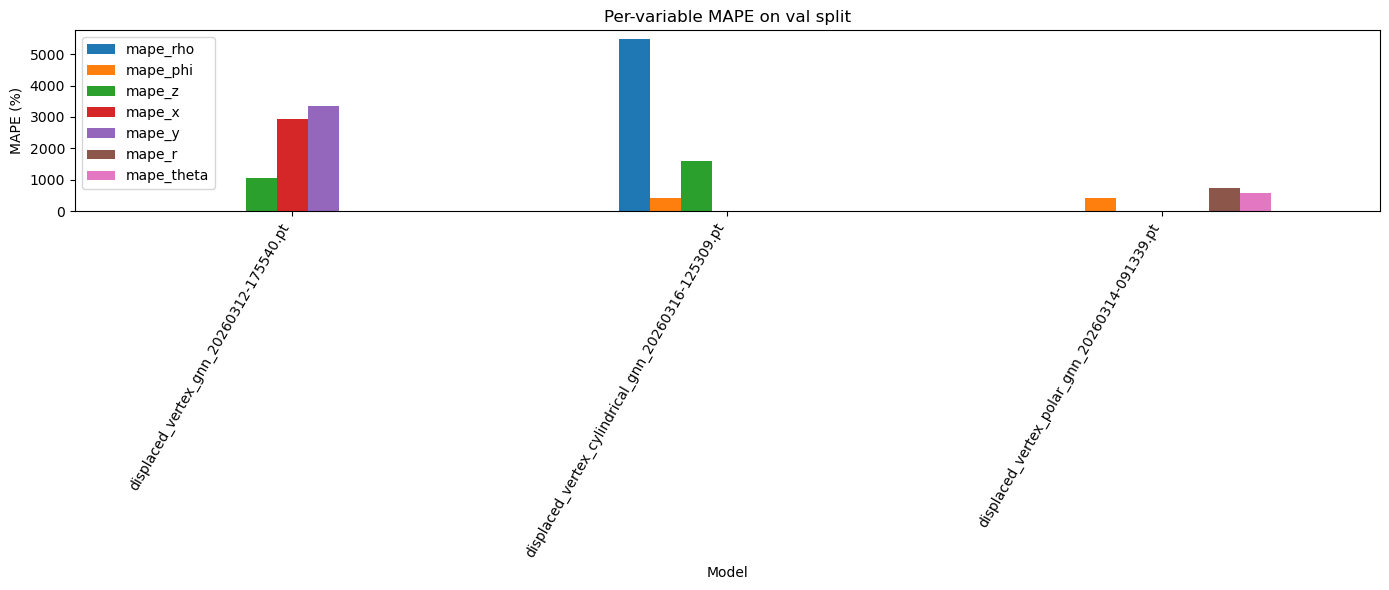

In [8]:
# ------------------------------
# Plot: Per-variable MAPE comparison
# ------------------------------

mape_cols = [c for c in results_df.columns if c.startswith("mape_")]

plt.figure(figsize=(14, 6))
plot_data = results_df.set_index("model")[mape_cols]
plot_data.plot(kind="bar", figsize=(14, 6))
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.title(f"Per-variable MAPE on {EVAL_SPLIT} split")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


In [9]:
# ------------------------------
# Pick one model for detailed plots
# ------------------------------

results_df[["model", "coordinate_system", "global_mape"]].sort_values("global_mape").reset_index(drop=True)


,model,coordinate_system,global_mape
0,displaced_vertex_polar_gnn_20260314-091339.pt,polar,572.625874
1,displaced_vertex_gnn_20260312-175540.pt,cartesian,2444.790473
2,displaced_vertex_cylindrical_gnn_20260316-1253...,cylindrical,2503.592897


In [10]:
# Set this to any model name from the table above
MODEL_TO_PLOT = results_df.sort_values("global_mape").iloc[0]["model"]
print("Selected model:", MODEL_TO_PLOT)

selected = result_store[MODEL_TO_PLOT]
preds = selected["preds"]
targets = selected["targets"]
labels = selected["labels"]
metrics = selected["metrics"]


Selected model: displaced_vertex_polar_gnn_20260314-091339.pt


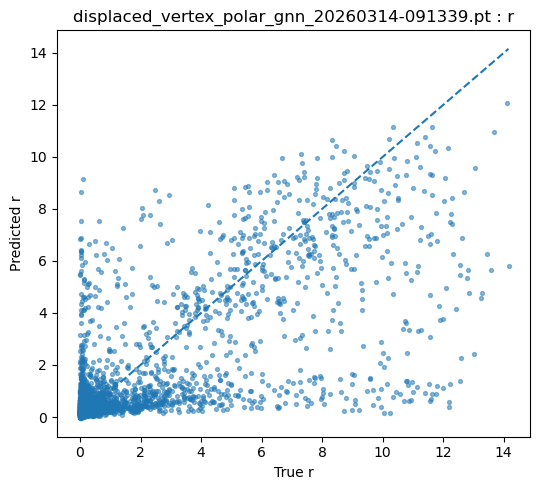

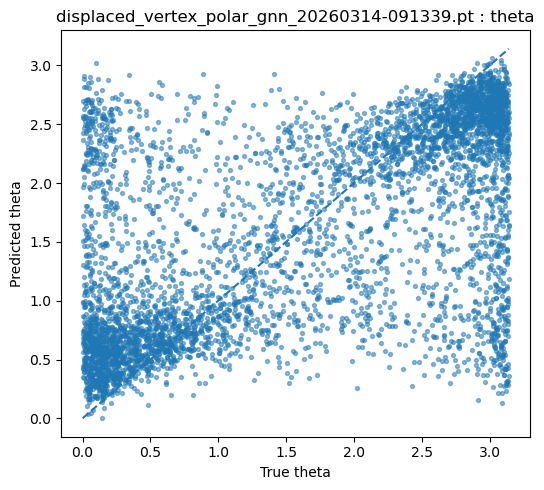

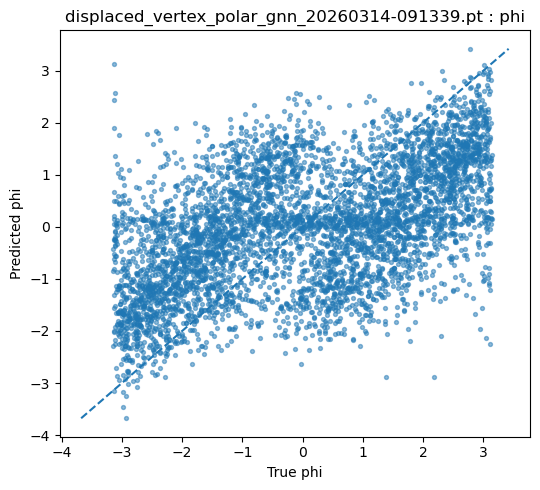

In [11]:
# ------------------------------
# Plot: prediction vs truth
# ------------------------------

rng = np.random.default_rng(12345)
n = len(preds)
if n > MAX_SCATTER_POINTS:
    take = rng.choice(n, size=MAX_SCATTER_POINTS, replace=False)
else:
    take = np.arange(n)

for i, lab in enumerate(labels):
    x_true = targets[take, i]
    y_pred = preds[take, i]

    plt.figure(figsize=(5.5, 5))
    plt.scatter(x_true, y_pred, s=8, alpha=0.5)
    lo = min(np.min(x_true), np.min(y_pred))
    hi = max(np.max(x_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel(f"True {lab}")
    plt.ylabel(f"Predicted {lab}")
    plt.title(f"{MODEL_TO_PLOT} : {lab}")
    plt.tight_layout()
    plt.show()


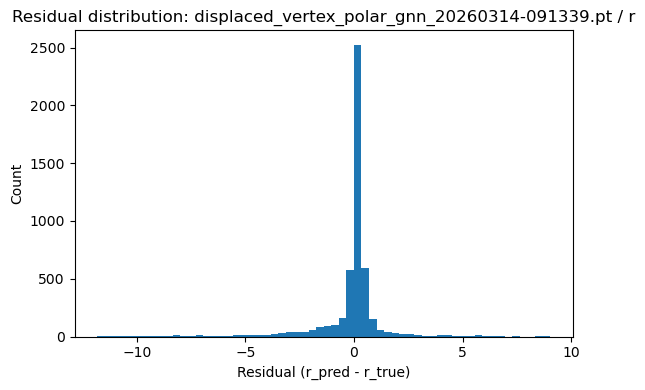

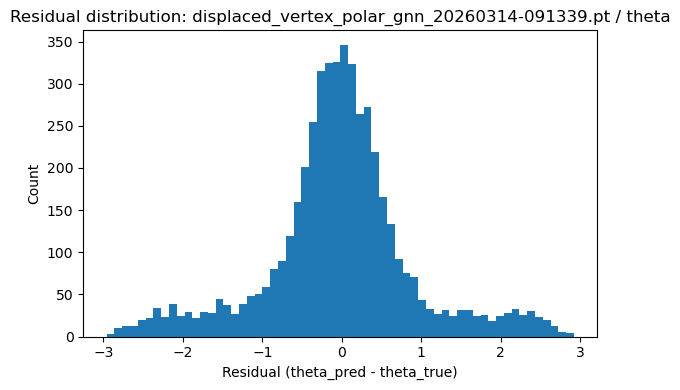

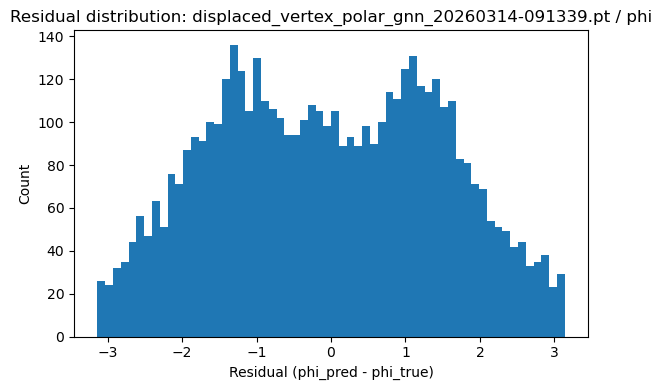

In [12]:
# ------------------------------
# Plot: residual histograms
# ------------------------------

diff = metrics["diff"]

for i, lab in enumerate(labels):
    plt.figure(figsize=(6, 4))
    plt.hist(diff[:, i], bins=60)
    plt.xlabel(f"Residual ({lab}_pred - {lab}_true)")
    plt.ylabel("Count")
    plt.title(f"Residual distribution: {MODEL_TO_PLOT} / {lab}")
    plt.tight_layout()
    plt.show()


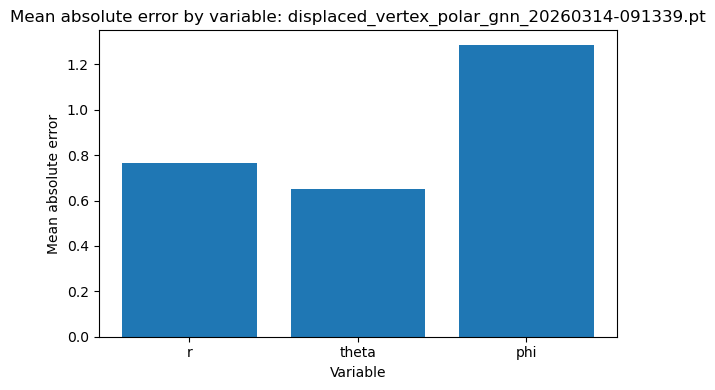

In [13]:
# ------------------------------
# Plot: absolute error by variable
# ------------------------------

abs_diff = metrics["abs_diff"]
mean_abs = abs_diff.mean(axis=0)

plt.figure(figsize=(6, 4))
plt.bar(labels, mean_abs)
plt.ylabel("Mean absolute error")
plt.xlabel("Variable")
plt.title(f"Mean absolute error by variable: {MODEL_TO_PLOT}")
plt.tight_layout()
plt.show()


In [14]:
# ------------------------------
# Optional: save summary CSV
# ------------------------------

out_csv = f"displaced_vertex_eval_{EVAL_SPLIT}.csv"
results_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)


Saved: displaced_vertex_eval_val.csv


Unified comparison in cylindrical coordinates [rho, phi, z]:


,model,native_coordinate_system,global_mae_cyl,global_rmse_cyl,global_mape_cyl
0,displaced_vertex_gnn_20260312-175540.pt,cartesian,0.736779,1.427236,1092.412022
1,displaced_vertex_polar_gnn_20260314-091339.pt,polar,0.802101,1.391965,3270.330181
2,displaced_vertex_cylindrical_gnn_20260316-1253...,cylindrical,0.865872,1.524537,2503.592897


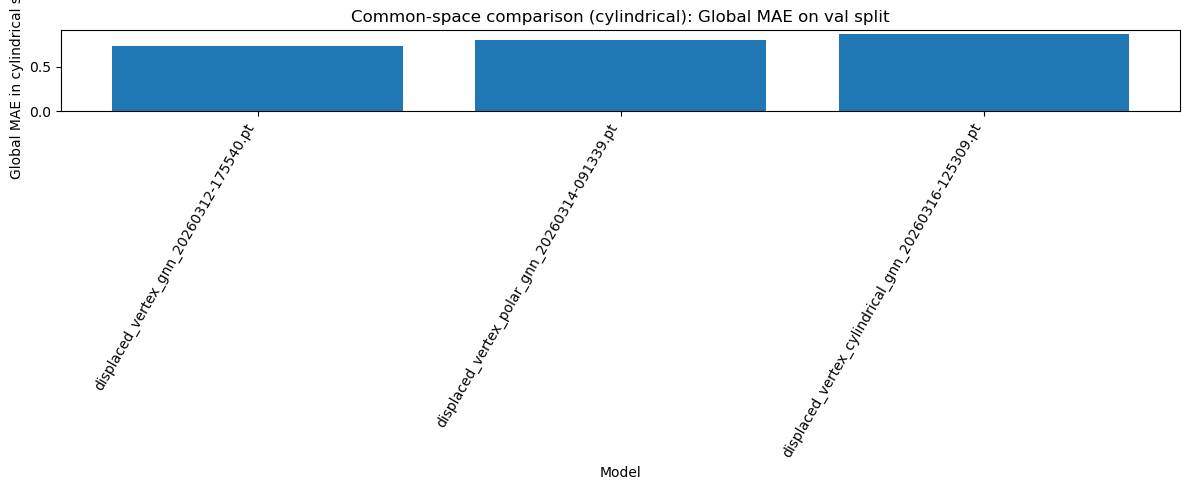

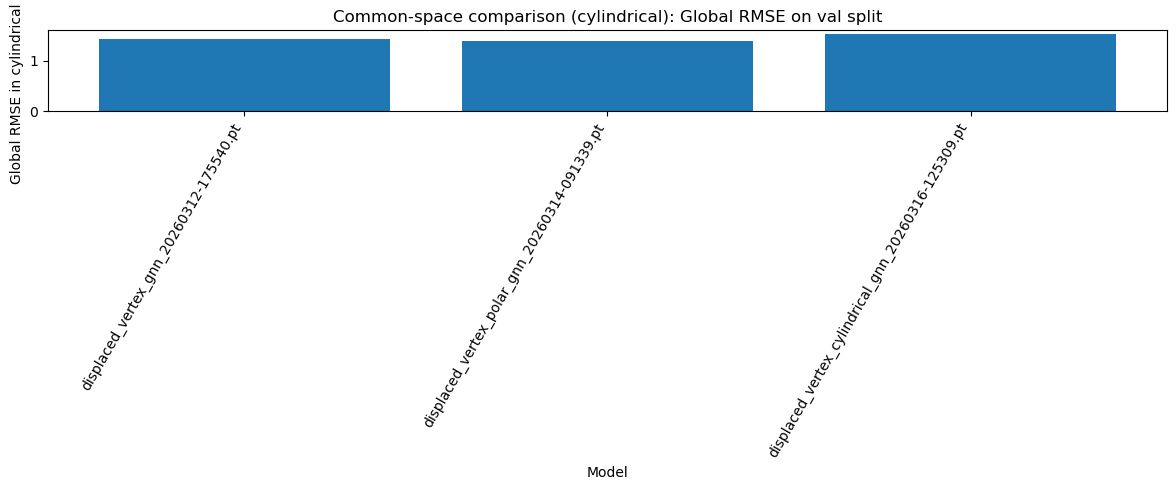

Native-coordinate metrics vs common cylindrical-coordinate metrics:


,model,coordinate_system,global_mae,global_rmse,global_mape,global_mae_cyl,global_rmse_cyl,global_mape_cyl
0,displaced_vertex_gnn_20260312-175540.pt,cartesian,0.384520,1.118442,2444.790473,0.736779,1.427236,1092.412022
1,displaced_vertex_polar_gnn_20260314-091339.pt,polar,0.900629,1.415203,572.625874,0.802101,1.391965,3270.330181
2,displaced_vertex_cylindrical_gnn_20260316-1253...,cylindrical,0.865872,1.524537,2503.592897,0.865872,1.524537,2503.592897


In [15]:
# ------------------------------
# Common-coordinate comparison (all models in cylindrical coordinates)
# ------------------------------

def to_cylindrical(values, labels):
    """
    Convert an array of shape (N, 3) from its native coordinate labels
    to cylindrical coordinates [rho, phi, z].
    Supported native labels:
      - [x, y, z]
      - [rho, phi, z]
      - [r, theta, phi]
    """
    vals = np.asarray(values, dtype=np.float64)
    labs = [str(l).lower() for l in labels]

    if labs == ["x", "y", "z"]:
        x, y, z = vals[:, 0], vals[:, 1], vals[:, 2]
        rho = np.sqrt(x**2 + y**2)
        phi = np.arctan2(y, x)
        return np.column_stack([rho, phi, z])

    if labs == ["rho", "phi", "z"]:
        rho, phi, z = vals[:, 0], vals[:, 1], vals[:, 2]
        phi = (phi + np.pi) % (2.0 * np.pi) - np.pi
        return np.column_stack([rho, phi, z])

    if labs == ["r", "theta", "phi"]:
        r, theta, phi = vals[:, 0], vals[:, 1], vals[:, 2]
        rho = r * np.sin(theta)
        z = r * np.cos(theta)
        phi = (phi + np.pi) % (2.0 * np.pi) - np.pi
        return np.column_stack([rho, phi, z])

    raise ValueError(f"Unsupported label order for conversion to cylindrical: {labels}")


cyl_rows = []
cyl_store = {}

for model_name, res in result_store.items():
    labels_native = res["labels"]
    preds_native = res["preds"]
    targets_native = res["targets"]

    preds_cyl = to_cylindrical(preds_native, labels_native)
    targets_cyl = to_cylindrical(targets_native, labels_native)

    cyl_metrics = compute_metrics(preds_cyl, targets_cyl, ["rho", "phi", "z"], mape_eps=MAPE_EPS)

    cyl_store[model_name] = {
        "preds_cyl": preds_cyl,
        "targets_cyl": targets_cyl,
        "metrics": cyl_metrics,
    }

    row = {
        "model": model_name,
        "native_coordinate_system": res["coordinate_system"],
        "global_mape_cyl": cyl_metrics["global_mape"],
        "global_mae_cyl": cyl_metrics["global_mae"],
        "global_rmse_cyl": cyl_metrics["global_rmse"],
        "mae_rho": cyl_metrics["per_var_mae"][0],
        "mae_phi": cyl_metrics["per_var_mae"][1],
        "mae_z": cyl_metrics["per_var_mae"][2],
        "rmse_rho": cyl_metrics["per_var_rmse"][0],
        "rmse_phi": cyl_metrics["per_var_rmse"][1],
        "rmse_z": cyl_metrics["per_var_rmse"][2],
        "mape_rho": cyl_metrics["per_var_mape"][0],
        "mape_phi": cyl_metrics["per_var_mape"][1],
        "mape_z": cyl_metrics["per_var_mape"][2],
    }
    cyl_rows.append(row)

results_cyl_df = (
    pd.DataFrame(cyl_rows)
    .sort_values(["global_mae_cyl", "global_rmse_cyl", "model"])
    .reset_index(drop=True)
)

print("Unified comparison in cylindrical coordinates [rho, phi, z]:")
display(
    results_cyl_df[
        [
            "model",
            "native_coordinate_system",
            "global_mae_cyl",
            "global_rmse_cyl",
            "global_mape_cyl",
        ]
    ]
)

# Plot global MAE and RMSE in common cylindrical coordinates
plot_cyl = results_cyl_df.copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_cyl["model"].astype(str), plot_cyl["global_mae_cyl"].astype(float))
plt.ylabel("Global MAE in cylindrical space")
plt.xlabel("Model")
plt.title(f"Common-space comparison (cylindrical): Global MAE on {EVAL_SPLIT} split")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_cyl["model"].astype(str), plot_cyl["global_rmse_cyl"].astype(float))
plt.ylabel("Global RMSE in cylindrical space")
plt.xlabel("Model")
plt.title(f"Common-space comparison (cylindrical): Global RMSE on {EVAL_SPLIT} split")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Optional: side-by-side native vs cylindrical-space metric for quick check
native_vs_cyl = (
    results_df[["model", "coordinate_system", "global_mae", "global_rmse", "global_mape"]]
    .merge(
        results_cyl_df[["model", "global_mae_cyl", "global_rmse_cyl", "global_mape_cyl"]],
        on="model",
        how="left",
    )
    .sort_values("global_mae_cyl")
    .reset_index(drop=True)
)

print("Native-coordinate metrics vs common cylindrical-coordinate metrics:")
display(native_vs_cyl)

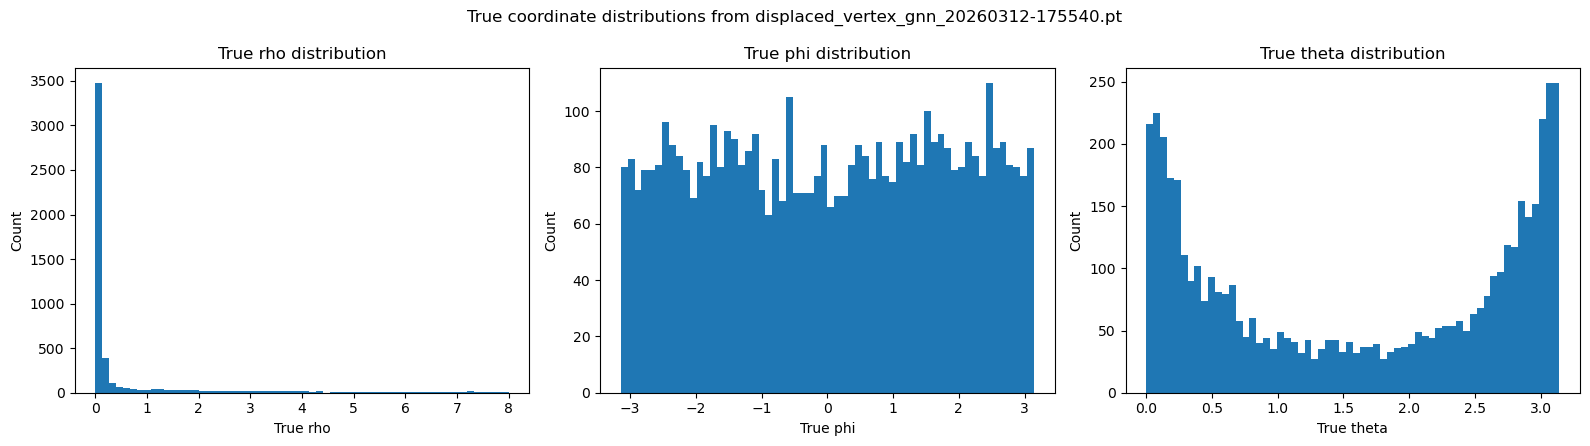

In [16]:
# ------------------------------
# Plot: true coordinate distributions (rho, phi, theta)
# ------------------------------

def to_cartesian(values, labels):
    vals = np.asarray(values, dtype=np.float64)
    labs = [str(l).lower() for l in labels]

    if labs == ["x", "y", "z"]:
        return vals.copy()

    if labs == ["rho", "phi", "z"]:
        rho, phi, z = vals[:, 0], vals[:, 1], vals[:, 2]
        x = rho * np.cos(phi)
        y = rho * np.sin(phi)
        return np.column_stack([x, y, z])

    if labs == ["r", "theta", "phi"]:
        r, theta, phi = vals[:, 0], vals[:, 1], vals[:, 2]
        x = r * np.sin(theta) * np.cos(phi)
        y = r * np.sin(theta) * np.sin(phi)
        z = r * np.cos(theta)
        return np.column_stack([x, y, z])

    raise ValueError(f"Unsupported label order for conversion to cartesian: {labels}")


if "results_cyl_df" in globals() and len(results_cyl_df) > 0:
    reference_model = results_cyl_df.iloc[0]["model"]
elif "results_df" in globals() and len(results_df) > 0:
    reference_model = results_df.iloc[0]["model"]
else:
    reference_model = next(iter(result_store))

reference_result = result_store[reference_model]
true_cart = to_cartesian(reference_result["targets"], reference_result["labels"])

x_true = true_cart[:, 0]
y_true = true_cart[:, 1]
z_true = true_cart[:, 2]

rho_true = np.sqrt(x_true**2 + y_true**2)
phi_true = np.arctan2(y_true, x_true)
theta_true = np.arctan2(rho_true, z_true)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(rho_true, bins=60)
axes[0].set_xlabel("True rho")
axes[0].set_ylabel("Count")
axes[0].set_title("True rho distribution")

axes[1].hist(phi_true, bins=60)
axes[1].set_xlabel("True phi")
axes[1].set_ylabel("Count")
axes[1].set_title("True phi distribution")

axes[2].hist(theta_true, bins=60)
axes[2].set_xlabel("True theta")
axes[2].set_ylabel("Count")
axes[2].set_title("True theta distribution")

plt.suptitle(f"True coordinate distributions from {reference_model}")
plt.tight_layout()
plt.show()

## Geometry Diagram: axes, rho, phi, theta

This diagram shows the coordinate definitions for one example point:

- `rho`: radial distance in the `xy` plane
- `phi`: azimuth angle in the `xy` plane from `+x`
- `theta`: polar angle from `+z` toward the point direction (range `[0, pi]`)

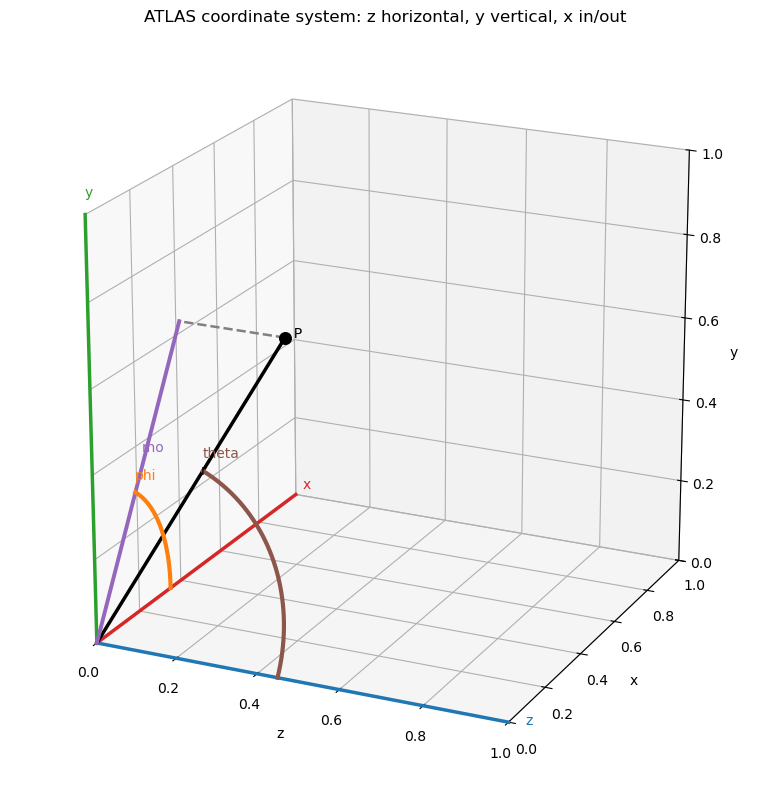

Physical point P = (0.024, 0.037, 0.016)
rho = 0.044, phi = 0.985 rad, theta = 1.230 rad


In [24]:

# 3D axis/angle diagram for one point in ATLAS-style polar convention:
# theta = atan2(rho, z) in [0, pi], phi = atan2(y, x) in [-pi, pi]
# Display orientation:
#   - z: left / right (horizontal, beam axis)      → matplotlib X axis
#   - y: vertical                                   → matplotlib Z axis
#   - x: in/out of the page (depth)                → matplotlib Y axis

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -------------------------------------------------
# 1) Pick one physical point (x, y, z)
# -------------------------------------------------
if "result_store" in globals() and len(result_store) > 0:
    model_for_geom = list(result_store.keys())[0]
    geom_labels = [str(v).lower() for v in result_store[model_for_geom]["labels"]]
    geom_target = np.asarray(result_store[model_for_geom]["targets"][0], dtype=np.float64)

    if geom_labels == ["x", "y", "z"]:
        x_p, y_p, z_p = geom_target
    elif geom_labels == ["rho", "phi", "z"]:
        rho0, phi0, z_p = geom_target
        x_p = rho0 * np.cos(phi0)
        y_p = rho0 * np.sin(phi0)
    elif geom_labels == ["r", "theta", "phi"]:
        r0, theta0, phi0 = geom_target
        x_p = r0 * np.sin(theta0) * np.cos(phi0)
        y_p = r0 * np.sin(theta0) * np.sin(phi0)
        z_p = r0 * np.cos(theta0)
    else:
        x_p, y_p, z_p = 0.7, 0.5, 0.9
else:
    x_p, y_p, z_p = 0.7, 0.5, 0.9

# Force all coordinates positive so arcs are in the visible first octant
x_p, y_p, z_p = abs(x_p), abs(y_p), abs(z_p)

# -------------------------------------------------
# 2) Compute angles in physical coordinates
# -------------------------------------------------
rho_p = np.sqrt(x_p**2 + y_p**2)
r_p = np.sqrt(x_p**2 + y_p**2 + z_p**2)
phi_p = np.arctan2(y_p, x_p)
theta_p = np.arctan2(rho_p, z_p)

# Use a scaled drawing point to keep arcs visible even when data point is near origin.
if r_p < 1e-9:
    u = np.array([0.45, 0.55, 0.70], dtype=np.float64)
    u = u / np.linalg.norm(u)
else:
    u = np.array([x_p, y_p, z_p], dtype=np.float64) / r_p

L = 1.0
draw_len = 0.80 * L
x_d, y_d, z_d = u * draw_len
rho_d = np.sqrt(x_d**2 + y_d**2)
phi_d = np.arctan2(y_d, x_d)
theta_d = np.arctan2(rho_d, z_d)

# Basis in physical space for theta arc
u_rho = np.array([np.cos(phi_d), np.sin(phi_d), 0.0], dtype=np.float64)
u_z   = np.array([0.0, 0.0, 1.0], dtype=np.float64)

# -------------------------------------------------
# 3) Coordinate transform for display orientation
# -------------------------------------------------
# physical (x, y, z) -> matplotlib (X, Y, Z)
#   matplotlib X = physical z  (horizontal, left-right)
#   matplotlib Y = physical x  (in/out, depth)
#   matplotlib Z = physical y  (vertical)
def to_display_xyz(x, y, z):
    return z, x, y

def map_curve(points_xyz):
    out = np.array([to_display_xyz(px, py, pz) for px, py, pz in points_xyz], dtype=np.float64)
    return out[:, 0], out[:, 1], out[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# -- Axis arrows --
# Physical z → display X (left-right): blue
ax.plot([0, L], [0, 0], [0, 0], color="tab:blue", linewidth=2.5)
ax.text(L * 1.04, 0, 0, "z", color="tab:blue")

# Physical x → display Y (in/out): red
ax.plot([0, 0], [0, L], [0, 0], color="tab:red", linewidth=2.5)
ax.text(0, L * 1.04, 0, "x", color="tab:red")

# Physical y → display Z (vertical): green
ax.plot([0, 0], [0, 0], [0, L], color="tab:green", linewidth=2.5)
ax.text(0, 0, L * 1.04, "y", color="tab:green")

# Point P (scaled for drawing)
Xd, Yd, Zd = to_display_xyz(x_d, y_d, z_d)
ax.scatter([Xd], [Yd], [Zd], color="black", s=70)
ax.text(Xd, Yd, Zd, "  P", color="black")

# r vector
Xr, Yr, Zr = map_curve(np.array([[0.0, 0.0, 0.0], [x_d, y_d, z_d]], dtype=np.float64))
ax.plot(Xr, Yr, Zr, color="black", linewidth=2.5)
ax.text(0.55 * Xd, 0.55 * Yd, 0.55 * Zd, "r", color="black")

# Projection to physical xy-plane (z=0), then transformed for display
proj_xy = np.array([x_d, y_d, 0.0], dtype=np.float64)
Xp, Yp, Zp = to_display_xyz(*proj_xy)
ax.plot([Xd, Xp], [Yd, Yp], [Zd, Zp], color="gray", linestyle="--", linewidth=1.8)

# rho segment in physical xy-plane
Xrho, Yrho, Zrho = map_curve(np.array([[0.0, 0.0, 0.0], [x_d, y_d, 0.0]], dtype=np.float64))
ax.plot(Xrho, Yrho, Zrho, color="tab:purple", linewidth=2.8)
ax.text(0.55 * Xrho[-1], 0.55 * Yrho[-1], 0.55 * Zrho[-1] + 0.03, "rho", color="tab:purple")

# phi arc in physical xy-plane
arc_phi_r = 0.35 * L
tphi = np.linspace(0.0, phi_d, 160)
phi_arc_phys = np.column_stack([
    arc_phi_r * np.cos(tphi),
    arc_phi_r * np.sin(tphi),
    np.zeros_like(tphi),
])
Xphi, Yphi, Zphi = map_curve(phi_arc_phys)
ax.plot(Xphi, Yphi, Zphi, color="tab:orange", linewidth=3.0)
ax.text(Xphi[-1], Yphi[-1], Zphi[-1] + 0.03, "phi", color="tab:orange")

# theta arc in plane spanned by +z and u_rho
arc_theta_r = 0.45 * L
ttheta = np.linspace(0.0, theta_d, 160)
theta_arc_phys = np.array([
    arc_theta_r * (np.sin(t) * u_rho + np.cos(t) * u_z)
    for t in ttheta
], dtype=np.float64)
Xth, Yth, Zth = map_curve(theta_arc_phys)
ax.plot(Xth, Yth, Zth, color="tab:brown", linewidth=3.0)
ax.text(Xth[-1], Yth[-1], Zth[-1] + 0.03, "theta", color="tab:brown")

ax.set_title("ATLAS coordinate system: z horizontal, y vertical, x in/out")
ax.set_xlabel("z")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=20, azim=-65)

plt.tight_layout()
plt.show()

print(f"Physical point P = ({x_p:.3f}, {y_p:.3f}, {z_p:.3f})")
print(f"rho = {rho_p:.3f}, phi = {phi_p:.3f} rad, theta = {theta_p:.3f} rad")